In [62]:
from src.data_loading import load_data
import numpy as np
import pandas as pd

df = load_data("../data/raw/train.csv")

# target
y = np.log1p(df["SalePrice"])

# features
x = df.drop(columns=["SalePrice"])

In [63]:
np.random.seed(42)

indices = np.random.permutation(len(x))
val_size = int(len(x) * 0.2)

val_idx = indices[:val_size]
train_idx = indices[val_size:]

x_train = x.iloc[train_idx].reset_index(drop=True)
x_val = x.iloc[val_idx].reset_index(drop=True)

y_train = y.iloc[train_idx].reset_index(drop=True)
y_val = y.iloc[val_idx].reset_index(drop=True)


In [64]:
x_train_num = x_train.select_dtypes(include=[np.number])
x_val_num = x_val.select_dtypes(include=[np.number])

mean = x_train_num.mean()
std = x_train_num.std()

x_train_num = (x_train_num - mean) / std
x_val_num = (x_val_num - mean) / std

In [65]:
numeric_cols = x_train.select_dtypes(include=[np.number]).columns

x_train_num = x_train[numeric_cols].copy()
x_val_num = x_val[numeric_cols].copy()

In [66]:
medians = x_train_num.median()

x_train_num = x_train_num.fillna(medians)
x_val_num = x_val_num.fillna(medians)

In [67]:
mean = x_train_num.mean()

std = x_train_num.std(ddof=0)
std = std.replace(0, 1.0)

x_train_num = (x_train_num - mean) / std
x_val_num = (x_val_num - mean) / std

In [68]:
x_train_np = x_train_num.to_numpy(dtype=np.float64)
x_val_np = x_val_num.to_numpy(dtype=np.float64)

y_train_np = y_train.to_numpy(dtype=np.float64)
y_val_np = y_val.to_numpy(dtype=np.float64)

In [69]:
x_train_np = np.hstack(
    (np.ones((x_train_np.shape[0], 1)), x_train_np)
)

x_val_np = np.hstack(
    (np.ones((x_val_np.shape[0], 1)), x_val_np)
)

In [70]:
from src.model import LinearRegression

model = LinearRegression(
    lr=0.01,
    n_epochs=1000,
    reg_lambda=0.01
)

model.fit(
    x_train_np,
    y_train_np,
    verbose=False
)

In [71]:
train_pred = model.predict(x_train_np)
val_pred = model.predict(x_val_np)

In [72]:
def rmse(y, yhat):
    return np.sqrt(np.mean((yhat - y) ** 2))

print("Train RMSE:", rmse(y_train_np, train_pred))
print("Val RMSE:", rmse(y_val_np, val_pred))

Train RMSE: 0.1440776283184795
Val RMSE: 0.15170037148356424


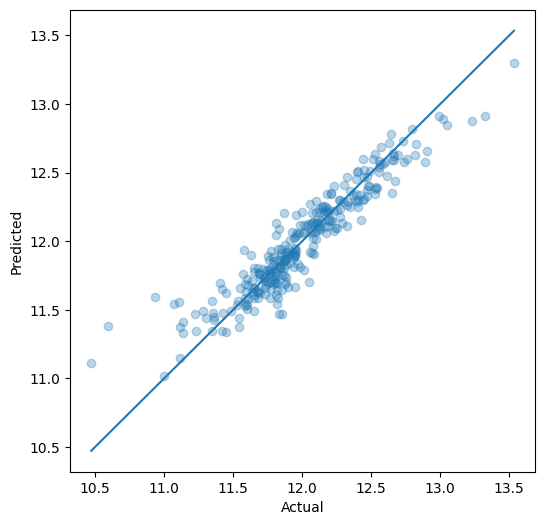

In [73]:
from matplotlib import pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_val_np, val_pred, alpha=0.3)

mn = min(y_val_np.min(), val_pred.min())
mx = max(y_val_np.max(), val_pred.max())

plt.plot([mn, mx], [mn, mx])

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()